In [58]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [59]:
conn = sqlite3.connect('nba_stats.db')

query = '''
SELECT s.*, a.offensive_win_shares AS ows, a.offensive_box_plus_minus AS obpm, b.minutes_played, t.team_name, t.gp AS team_gp
FROM scoring_plus AS s
JOIN basic_stats AS b ON s.slug = b.slug AND s.season_end_year = b.season_end_year
JOIN advanced_stats AS a ON s.slug = a.slug AND s.season_end_year = a.season_end_year
JOIN per_100_stats AS p ON s.slug = p.slug AND s.season_end_year = p.season_end_year
JOIN team_per_100_stats AS t ON p.team_id = t.team_id AND p.season_end_year = t.season_end_year
'''
scoring_plus_df = pd.read_sql_query(query, conn)
conn.close()

scoring_plus_df

,season_end_year,slug,name,per_100_pts,true_shooting_percentage,league_avg_per_100_pts_per_player,league_avg_true_shooting_percentage,pts_plus,ts_plus,scoring_plus,ows,obpm,minutes_played,team_name,team_gp
0,2001,greenac01,A.C. Green,13.8,0.492,20.311034,0.518,67.943364,94.980695,81.462029,1.1,-2.2,1411,Miami Heat,82
1,2001,guytoaj01,A.J. Guyton,16.9,0.495,20.311034,0.518,83.206003,95.559846,89.382924,0.4,-0.8,630,Chicago Bulls,82
2,2001,mckieaa01,Aaron McKie,18.9,0.549,20.311034,0.518,93.052867,105.984556,99.518712,2.3,0.1,2394,Philadelphia 76ers,82
3,2001,williaa01,Aaron Williams,18.5,0.533,20.311034,0.518,91.083495,102.895753,96.989624,2.9,-1.3,2336,New Jersey Nets,82
4,2001,keefead01,Adam Keefe,10.1,0.450,20.311034,0.518,49.726665,86.872587,68.299626,0.1,-3.5,836,Golden State Warriors,82
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12797,2026,lavinza01,Zach LaVine,29.1,0.614,22.957333,0.581,126.756882,105.679862,116.218372,1.3,0.6,1224,Sacramento Kings,82
12798,2026,nnajize01,Zeke Nnaji,14.8,0.558,22.957333,0.581,64.467418,96.041308,80.254363,0.2,-3.6,626,Denver Nuggets,82
12799,2026,willizi02,Ziaire Williams,21.4,0.579,22.957333,0.581,93.216401,99.655766,96.436084,0.5,-2.0,1281,Brooklyn Nets,82
12800,2026,willizi01,Zion Williamson,32.8,0.644,22.957333,0.581,142.873737,110.843373,126.858555,5.0,3.5,1841,New Orleans Pelicans,82


In [60]:
scoring_plus_df['threshold'] = 1500 * (scoring_plus_df['team_gp'] / 82)

In [61]:
scoring_plus_qualified_df = scoring_plus_df[scoring_plus_df['minutes_played'] >= scoring_plus_df['threshold']].copy()

scoring_plus_qualified_df.reset_index(drop=True, inplace=True)
scoring_plus_qualified_df

,season_end_year,slug,name,per_100_pts,true_shooting_percentage,league_avg_per_100_pts_per_player,league_avg_true_shooting_percentage,pts_plus,ts_plus,scoring_plus,ows,obpm,minutes_played,team_name,team_gp,threshold
0,2001,mckieaa01,Aaron McKie,18.9,0.549,20.311034,0.518,93.052867,105.984556,99.518712,2.3,0.1,2394,Philadelphia 76ers,82,1500.0
1,2001,williaa01,Aaron Williams,18.5,0.533,20.311034,0.518,91.083495,102.895753,96.989624,2.9,-1.3,2336,New Jersey Nets,82,1500.0
2,2001,harrial01,Al Harrington,16.2,0.479,20.311034,0.518,79.759601,92.471042,86.115322,-1.0,-3.3,1892,Indiana Pacers,82,1500.0
3,2001,hendeal01,Alan Henderson,21.5,0.487,20.311034,0.518,105.853791,94.015444,99.934618,0.5,-1.2,1810,Atlanta Hawks,82,1500.0
4,2001,houstal01,Allan Houston,27.6,0.543,20.311034,0.518,135.886727,104.826255,120.356491,4.1,1.3,2858,New York Knicks,82,1500.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4860,2026,wembavi01,Victor Wembanyama,40.2,0.626,22.957333,0.581,175.107446,107.745267,141.426356,5.0,6.5,1866,San Antonio Spurs,82,1500.0
4861,2026,cartewe01,Wendell Carter Jr.,19.1,0.617,22.957333,0.581,83.197816,106.196213,94.697015,3.4,-1.0,2288,Orlando Magic,82,1500.0
4862,2026,rileywi01,Will Riley,21.7,0.548,22.957333,0.581,94.523173,94.320138,94.421656,0.4,-1.9,1633,Washington Wizards,82,1500.0
4863,2026,risacza01,Zaccharie Risacher,19.5,0.557,22.957333,0.581,84.940179,95.869191,90.404685,0.5,-2.3,1503,Atlanta Hawks,82,1500.0


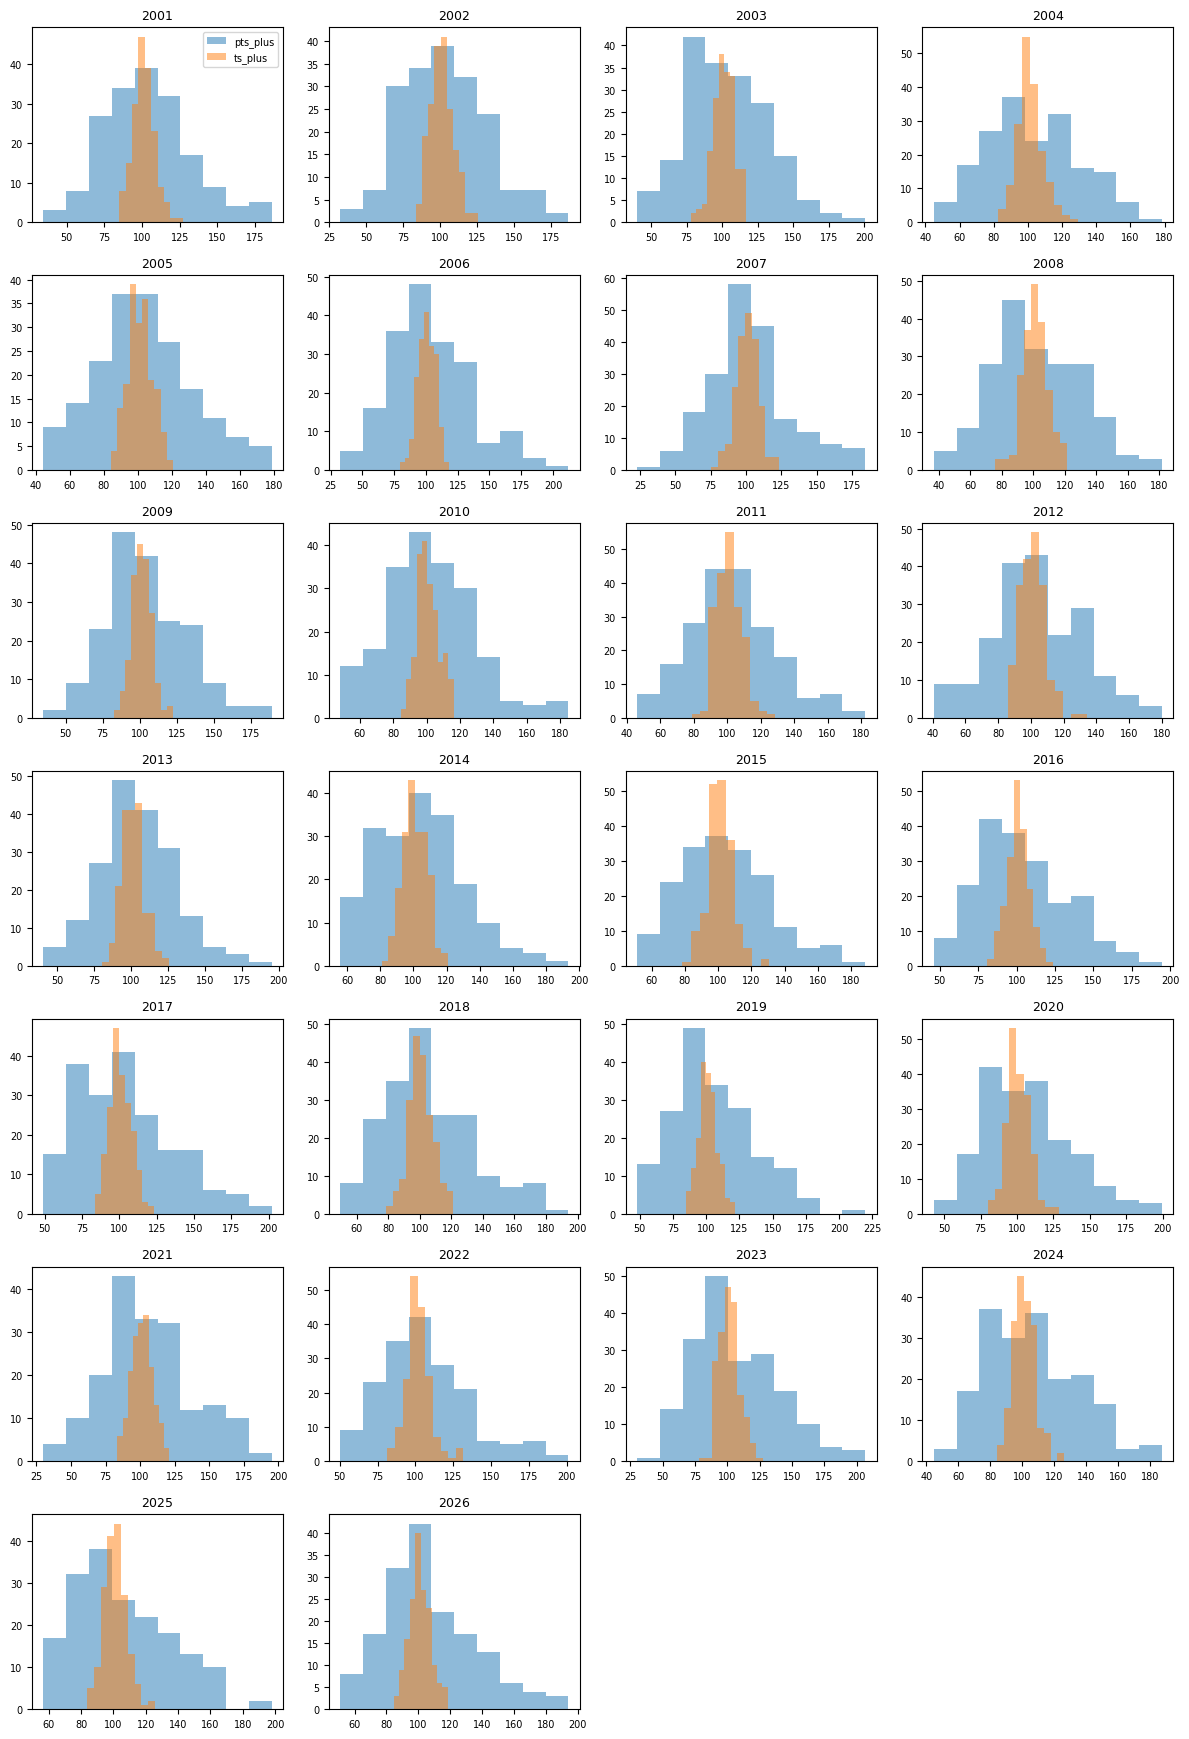

In [62]:
seasons = sorted(scoring_plus_qualified_df['season_end_year'].unique())
n_cols = 4
n_rows = -(-len(seasons) // n_cols)  # ceil division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 2.5))
axes = axes.flatten()

for ax, season in zip(axes, seasons):
    season_df = scoring_plus_qualified_df[scoring_plus_qualified_df['season_end_year'] == season]

    ax.hist(season_df['pts_plus'], alpha=0.5, label='pts_plus')
    ax.hist(season_df['ts_plus'], alpha=0.5, label='ts_plus')
    ax.set_title(season, fontsize=9)
    ax.tick_params(labelsize=7)

for ax in axes[len(seasons):]:
    ax.axis('off')

axes[0].legend(fontsize=7)
plt.tight_layout()
plt.show()

In [63]:
scoring_plus_qualified_df['z_pts_plus'] = (scoring_plus_qualified_df['pts_plus'] - scoring_plus_qualified_df.groupby('season_end_year')['pts_plus'].transform('mean')) / scoring_plus_qualified_df.groupby('season_end_year')['pts_plus'].transform('std')
scoring_plus_qualified_df['z_ts_plus'] = (scoring_plus_qualified_df['ts_plus'] - scoring_plus_qualified_df.groupby('season_end_year')['ts_plus'].transform('mean')) / scoring_plus_qualified_df.groupby('season_end_year')['ts_plus'].transform('std')

scoring_plus_qualified_df

,season_end_year,slug,name,per_100_pts,true_shooting_percentage,league_avg_per_100_pts_per_player,league_avg_true_shooting_percentage,pts_plus,ts_plus,scoring_plus,ows,obpm,minutes_played,team_name,team_gp,threshold,z_pts_plus,z_ts_plus
0,2001,mckieaa01,Aaron McKie,18.9,0.549,20.311034,0.518,93.052867,105.984556,99.518712,2.3,0.1,2394,Philadelphia 76ers,82,1500.0,-0.368674,0.676839
1,2001,williaa01,Aaron Williams,18.5,0.533,20.311034,0.518,91.083495,102.895753,96.989624,2.9,-1.3,2336,New Jersey Nets,82,1500.0,-0.438228,0.240919
2,2001,harrial01,Al Harrington,16.2,0.479,20.311034,0.518,79.759601,92.471042,86.115322,-1.0,-3.3,1892,Indiana Pacers,82,1500.0,-0.838162,-1.230310
3,2001,hendeal01,Alan Henderson,21.5,0.487,20.311034,0.518,105.853791,94.015444,99.934618,0.5,-1.2,1810,Atlanta Hawks,82,1500.0,0.083425,-1.012350
4,2001,houstal01,Allan Houston,27.6,0.543,20.311034,0.518,135.886727,104.826255,120.356491,4.1,1.3,2858,New York Knicks,82,1500.0,1.144121,0.513369
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4860,2026,wembavi01,Victor Wembanyama,40.2,0.626,22.957333,0.581,175.107446,107.745267,141.426356,5.0,6.5,1866,San Antonio Spurs,82,1500.0,2.342639,1.006273
4861,2026,cartewe01,Wendell Carter Jr.,19.1,0.617,22.957333,0.581,83.197816,106.196213,94.697015,3.4,-1.0,2288,Orlando Magic,82,1500.0,-0.816792,0.774020
4862,2026,rileywi01,Will Riley,21.7,0.548,22.957333,0.581,94.523173,94.320138,94.421656,0.4,-1.9,1633,Washington Wizards,82,1500.0,-0.427478,-1.006588
4863,2026,risacza01,Zaccharie Risacher,19.5,0.557,22.957333,0.581,84.940179,95.869191,90.404685,0.5,-2.3,1503,Atlanta Hawks,82,1500.0,-0.756898,-0.774335


In [64]:
print(scoring_plus_qualified_df[['z_ts_plus', 'z_pts_plus']].corr())

            z_ts_plus  z_pts_plus
z_ts_plus    1.000000    0.264457
z_pts_plus   0.264457    1.000000


In [65]:
scoring_plus_qualified_df['z_ows'] = (scoring_plus_qualified_df['ows'] - scoring_plus_qualified_df.groupby('season_end_year')['ows'].transform('mean')) / scoring_plus_qualified_df.groupby('season_end_year')['ows'].transform('std')
scoring_plus_qualified_df['z_obpm'] = (scoring_plus_qualified_df['obpm'] - scoring_plus_qualified_df.groupby('season_end_year')['obpm'].transform('mean')) / scoring_plus_qualified_df.groupby('season_end_year')['obpm'].transform('std')

scoring_plus_qualified_df

,season_end_year,slug,name,per_100_pts,true_shooting_percentage,league_avg_per_100_pts_per_player,league_avg_true_shooting_percentage,pts_plus,ts_plus,scoring_plus,ows,obpm,minutes_played,team_name,team_gp,threshold,z_pts_plus,z_ts_plus,z_ows,z_obpm
0,2001,mckieaa01,Aaron McKie,18.9,0.549,20.311034,0.518,93.052867,105.984556,99.518712,2.3,0.1,2394,Philadelphia 76ers,82,1500.0,-0.368674,0.676839,-0.353768,-0.177122
1,2001,williaa01,Aaron Williams,18.5,0.533,20.311034,0.518,91.083495,102.895753,96.989624,2.9,-1.3,2336,New Jersey Nets,82,1500.0,-0.438228,0.240919,-0.125337,-0.775209
2,2001,harrial01,Al Harrington,16.2,0.479,20.311034,0.518,79.759601,92.471042,86.115322,-1.0,-3.3,1892,Indiana Pacers,82,1500.0,-0.838162,-1.230310,-1.610134,-1.629618
3,2001,hendeal01,Alan Henderson,21.5,0.487,20.311034,0.518,105.853791,94.015444,99.934618,0.5,-1.2,1810,Atlanta Hawks,82,1500.0,0.083425,-1.012350,-1.039058,-0.732488
4,2001,houstal01,Allan Houston,27.6,0.543,20.311034,0.518,135.886727,104.826255,120.356491,4.1,1.3,2858,New York Knicks,82,1500.0,1.144121,0.513369,0.331523,0.335524
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4860,2026,wembavi01,Victor Wembanyama,40.2,0.626,22.957333,0.581,175.107446,107.745267,141.426356,5.0,6.5,1866,San Antonio Spurs,82,1500.0,2.342639,1.006273,1.102412,2.386974
4861,2026,cartewe01,Wendell Carter Jr.,19.1,0.617,22.957333,0.581,83.197816,106.196213,94.697015,3.4,-1.0,2288,Orlando Magic,82,1500.0,-0.816792,0.774020,0.329162,-0.719224
4862,2026,rileywi01,Will Riley,21.7,0.548,22.957333,0.581,94.523173,94.320138,94.421656,0.4,-1.9,1633,Washington Wizards,82,1500.0,-0.427478,-1.006588,-1.120682,-1.091968
4863,2026,risacza01,Zaccharie Risacher,19.5,0.557,22.957333,0.581,84.940179,95.869191,90.404685,0.5,-2.3,1503,Atlanta Hawks,82,1500.0,-0.756898,-0.774335,-1.072354,-1.257631


In [66]:
X = scoring_plus_qualified_df[['z_ts_plus', 'z_pts_plus']]
X = sm.add_constant(X)  # adds an intercept term
y = scoring_plus_qualified_df['z_ows']

model_ows = sm.OLS(y, X, missing='drop').fit()  # missing='drop' skips rows with NaN in X or y
print(model_ows.summary())

                            OLS Regression Results                            
Dep. Variable:                  z_ows   R-squared:                       0.657
Model:                            OLS   Adj. R-squared:                  0.657
Method:                 Least Squares   F-statistic:                     4656.
Date:                Tue, 21 Jul 2026   Prob (F-statistic):               0.00
Time:                        14:54:41   Log-Likelihood:                -4287.4
No. Observations:                4865   AIC:                             8581.
Df Residuals:                    4862   BIC:                             8600.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.495e-17      0.008   2.98e-15      1.0

In [67]:
beta1_ows = model_ows.params['z_ts_plus']
beta2_ows = model_ows.params['z_pts_plus']
print(f"Beta for z_ts_plus: {beta1_ows}, Beta for z_pts_plus: {beta2_ows}")

Beta for z_ts_plus: 0.588163025956513, Beta for z_pts_plus: 0.4234540917591018


In [68]:
X = scoring_plus_qualified_df[['z_ts_plus', 'z_pts_plus']]
X = sm.add_constant(X)  # adds an intercept term
y = scoring_plus_qualified_df['z_obpm']

model_obpm = sm.OLS(y, X, missing='drop').fit()  # missing='drop' skips rows with NaN in X or y
print(model_obpm.summary())

                            OLS Regression Results                            
Dep. Variable:                 z_obpm   R-squared:                       0.736
Model:                            OLS   Adj. R-squared:                  0.736
Method:                 Least Squares   F-statistic:                     6783.
Date:                Tue, 21 Jul 2026   Prob (F-statistic):               0.00
Time:                        14:54:41   Log-Likelihood:                -3649.1
No. Observations:                4865   AIC:                             7304.
Df Residuals:                    4862   BIC:                             7324.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.251e-17      0.007   3.06e-15      1.0

In [69]:
beta1_obpm = model_obpm.params['z_ts_plus']
beta2_obpm = model_obpm.params['z_pts_plus']
print(f"Beta for z_ts_plus: {beta1_obpm}, Beta for z_pts_plus: {beta2_obpm}")

Beta for z_ts_plus: 0.349088942859401, Beta for z_pts_plus: 0.6968669440035584


In [70]:
final_beta1 = (beta1_ows + beta1_obpm) / 2
final_beta2 = (beta2_ows + beta2_obpm) / 2
print(f"Final Beta for z_ts_plus: {final_beta1}, Final Beta for z_pts_plus: {final_beta2}")

Final Beta for z_ts_plus: 0.468625984407957, Final Beta for z_pts_plus: 0.5601605178813301


In [73]:
sd_ts_plus = scoring_plus_qualified_df['ts_plus'].std()
sd_pts_plus = scoring_plus_qualified_df['pts_plus'].std()

c1 = final_beta1 / sd_ts_plus
c2 = final_beta2 / sd_pts_plus

w1 = c1 / (c1 + c2)
w2 = c2 / (c1 + c2)

w1 = round(w1, 3)
w2 = round(w2, 3)

print(f"Weight for ts_plus: {w1}, Weight for pts_plus: {w2}")

Weight for ts_plus: 0.765, Weight for pts_plus: 0.235


In [74]:
scoring_plus_qualified_df['new_scoring_plus'] = (
    100
    + (0.765 * (scoring_plus_qualified_df['ts_plus'] - 100))
    + (0.235 * (scoring_plus_qualified_df['pts_plus'] - 100))
)
scoring_plus_qualified_df

,season_end_year,slug,name,per_100_pts,true_shooting_percentage,league_avg_per_100_pts_per_player,league_avg_true_shooting_percentage,pts_plus,ts_plus,scoring_plus,...,obpm,minutes_played,team_name,team_gp,threshold,z_pts_plus,z_ts_plus,z_ows,z_obpm,new_scoring_plus
0,2001,mckieaa01,Aaron McKie,18.9,0.549,20.311034,0.518,93.052867,105.984556,99.518712,...,0.1,2394,Philadelphia 76ers,82,1500.0,-0.368674,0.676839,-0.353768,-0.177122,102.945609
1,2001,williaa01,Aaron Williams,18.5,0.533,20.311034,0.518,91.083495,102.895753,96.989624,...,-1.3,2336,New Jersey Nets,82,1500.0,-0.438228,0.240919,-0.125337,-0.775209,100.119872
2,2001,harrial01,Al Harrington,16.2,0.479,20.311034,0.518,79.759601,92.471042,86.115322,...,-3.3,1892,Indiana Pacers,82,1500.0,-0.838162,-1.230310,-1.610134,-1.629618,89.483854
3,2001,hendeal01,Alan Henderson,21.5,0.487,20.311034,0.518,105.853791,94.015444,99.934618,...,-1.2,1810,Atlanta Hawks,82,1500.0,0.083425,-1.012350,-1.039058,-0.732488,96.797456
4,2001,houstal01,Allan Houston,27.6,0.543,20.311034,0.518,135.886727,104.826255,120.356491,...,1.3,2858,New York Knicks,82,1500.0,1.144121,0.513369,0.331523,0.335524,112.125466
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4860,2026,wembavi01,Victor Wembanyama,40.2,0.626,22.957333,0.581,175.107446,107.745267,141.426356,...,6.5,1866,San Antonio Spurs,82,1500.0,2.342639,1.006273,1.102412,2.386974,123.575379
4861,2026,cartewe01,Wendell Carter Jr.,19.1,0.617,22.957333,0.581,83.197816,106.196213,94.697015,...,-1.0,2288,Orlando Magic,82,1500.0,-0.816792,0.774020,0.329162,-0.719224,100.791590
4862,2026,rileywi01,Will Riley,21.7,0.548,22.957333,0.581,94.523173,94.320138,94.421656,...,-1.9,1633,Washington Wizards,82,1500.0,-0.427478,-1.006588,-1.120682,-1.091968,94.367851
4863,2026,risacza01,Zaccharie Risacher,19.5,0.557,22.957333,0.581,84.940179,95.869191,90.404685,...,-2.3,1503,Atlanta Hawks,82,1500.0,-0.756898,-0.774335,-1.072354,-1.257631,93.300873


In [75]:
top_25_scoring_plus = scoring_plus_qualified_df.sort_values(by='new_scoring_plus', ascending=False).head(25)
top_25_scoring_plus

,season_end_year,slug,name,per_100_pts,true_shooting_percentage,league_avg_per_100_pts_per_player,league_avg_true_shooting_percentage,pts_plus,ts_plus,scoring_plus,...,obpm,minutes_played,team_name,team_gp,threshold,z_pts_plus,z_ts_plus,z_ows,z_obpm,new_scoring_plus
3008,2016,curryst01,Stephen Curry,41.1,0.669,21.112000,0.541,194.676014,123.659889,159.167951,...,10.3,2700,Golden State Warriors,82,1500.000000,3.190857,3.206923,4.596564,4.364599,140.348678
3494,2019,hardeja01,James Harden,48.2,0.616,21.944000,0.560,219.650018,110.000000,164.825009,...,9.4,2867,Houston Rockets,82,1500.000000,3.795442,1.228077,3.898692,3.638669,135.767754
2564,2014,duranke01,Kevin Durant,40.9,0.635,21.136667,0.541,193.502602,117.375231,155.438917,...,8.8,3122,Oklahoma City Thunder,82,1500.000000,3.433512,2.306855,4.932397,4.009980,135.265163
4242,2023,embiijo01,Joel Embiid,47.1,0.655,22.815333,0.581,206.440113,112.736661,159.588387,...,6.8,2284,Philadelphia 76ers,82,1500.000000,3.040187,1.446515,2.647770,2.437569,134.756972
2376,2013,duranke01,Kevin Durant,37.2,0.647,20.952000,0.535,177.548683,120.934579,149.241631,...,7.6,3119,Oklahoma City Thunder,82,1500.000000,2.891744,2.581508,4.393246,3.341811,134.238894
3395,2018,curryst01,Stephen Curry,37.7,0.675,21.568000,0.556,174.795994,121.402878,148.099436,...,7.8,1631,Golden State Warriors,82,1500.000000,2.517880,2.654702,1.934898,3.164517,133.950260
1306,2008,stoudam01,Amar'e Stoudemire,36.5,0.656,21.239333,0.540,171.850968,121.481481,146.666225,...,4.2,2677,Phoenix Suns,82,1500.000000,2.536686,2.545929,3.099913,1.719387,133.318311
2576,2014,jamesle01,LeBron James,37.1,0.649,21.136667,0.541,175.524365,119.963031,147.743698,...,7.8,2902,Miami Heat,82,1500.000000,2.742291,2.668236,3.895124,3.524542,133.019945
4847,2026,gilgesh01,Shai Gilgeous-Alexander,44.1,0.665,22.957333,0.581,192.095481,114.457831,153.276656,...,8.7,2259,Oklahoma City Thunder,82,1500.000000,2.926610,2.012703,4.050427,3.298126,132.702679
2393,2013,jamesle01,LeBron James,36.7,0.640,20.952000,0.535,175.162276,119.626168,147.394222,...,9.3,2877,Miami Heat,82,1500.000000,2.797638,2.409259,4.807828,4.156756,132.677153
